# Loan Default Prediction

**Goal:** Predict whether a loan applicant will default, using demographic,
financial, and employment data, to support data-driven credit risk decisions.

**Dataset:** 15,000 historical loan records with 10 borrower attributes and
a binary `loan_default` label (15% positive class).

**Approach:**
1. Exploratory data analysis
2. Feature engineering (debt-to-income, employment stability, etc.)
3. Train/compare Logistic Regression, Random Forest, and Gradient Boosting
4. Hyperparameter tuning with `GridSearchCV`
5. Evaluation with ROC-AUC, precision/recall, and confusion matrix
6. Inference on new applicants

---


In [1]:
import sys
sys.path.append("../src")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from preprocessing import (
    load_data, engineer_features, get_feature_lists,
    build_preprocessor, train_test_split_data
)

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", None)


## 1. Load and inspect the data

In [2]:
df = load_data("../data/cleaned_loan_default_data.csv")
print(df.shape)
df.head()


(15000, 11)


,age,annual_income,loan_amount,credit_score,years_employed,num_credit_cards,gender,education,marital_status,employment_type,loan_default
0,59,51994.837181,16764.016548,750.780562,20,4,Male,High School,Single,Salaried,0
1,49,63263.880493,39343.041526,632.231535,18,7,Female,Graduate,Married,Salaried,0
2,35,45597.147997,27950.628637,784.355622,31,2,Female,Masters,Single,Self Employed,0
3,63,74140.350059,17736.430853,580.604474,10,6,Female,High School,Single,Self Employed,0
4,28,54340.474460,26330.913608,690.563743,17,0,Female,High School,Single,Self Employed,0


In [3]:
df.describe()


,age,annual_income,loan_amount,credit_score,years_employed,num_credit_cards,loan_default
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,42.484000,60575.548965,25005.207840,680.238999,17.046133,4.485400,0.150000
std,12.584992,19577.542258,9820.132405,76.748744,10.141285,2.871365,0.357083
min,21.000000,15000.000000,1000.000000,477.292943,0.000000,0.000000,0.000000
25%,32.000000,47634.999060,18119.957123,629.302761,8.000000,2.000000,0.000000
50%,42.000000,60369.092451,24937.459009,680.690262,17.000000,4.000000,0.000000
75%,53.000000,73308.187804,31685.094258,730.642640,26.000000,7.000000,0.000000
max,64.000000,111817.970921,52032.799962,850.000000,34.000000,9.000000,1.000000


In [4]:
df["loan_default"].value_counts(normalize=True).rename("proportion")


loan_default
0    0.85
1    0.15
Name: proportion, dtype: float64

The dataset is imbalanced — only 15% of borrowers defaulted. This is handled
later via `class_weight="balanced"` for linear/tree models and is reflected
in our choice of evaluation metrics (precision, recall, ROC-AUC rather than
accuracy alone).

## 2. Exploratory Data Analysis

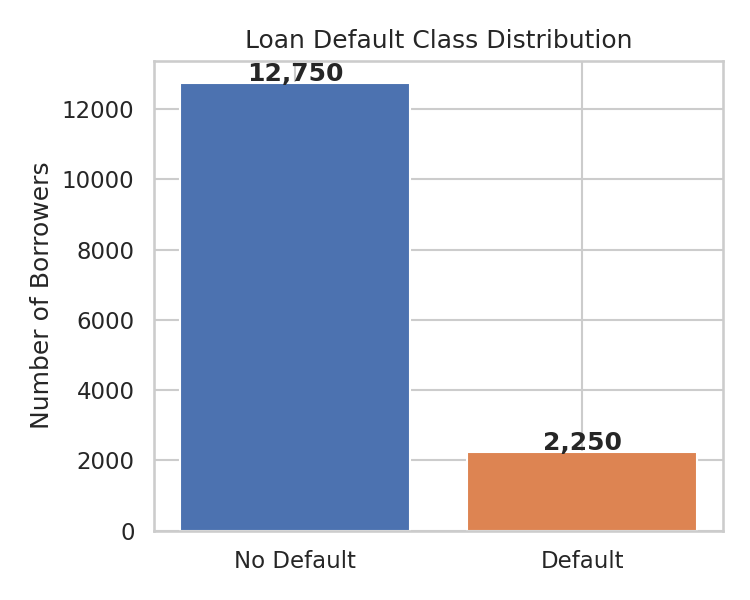

In [5]:
from IPython.display import Image
Image(filename="../images/class_balance.png")


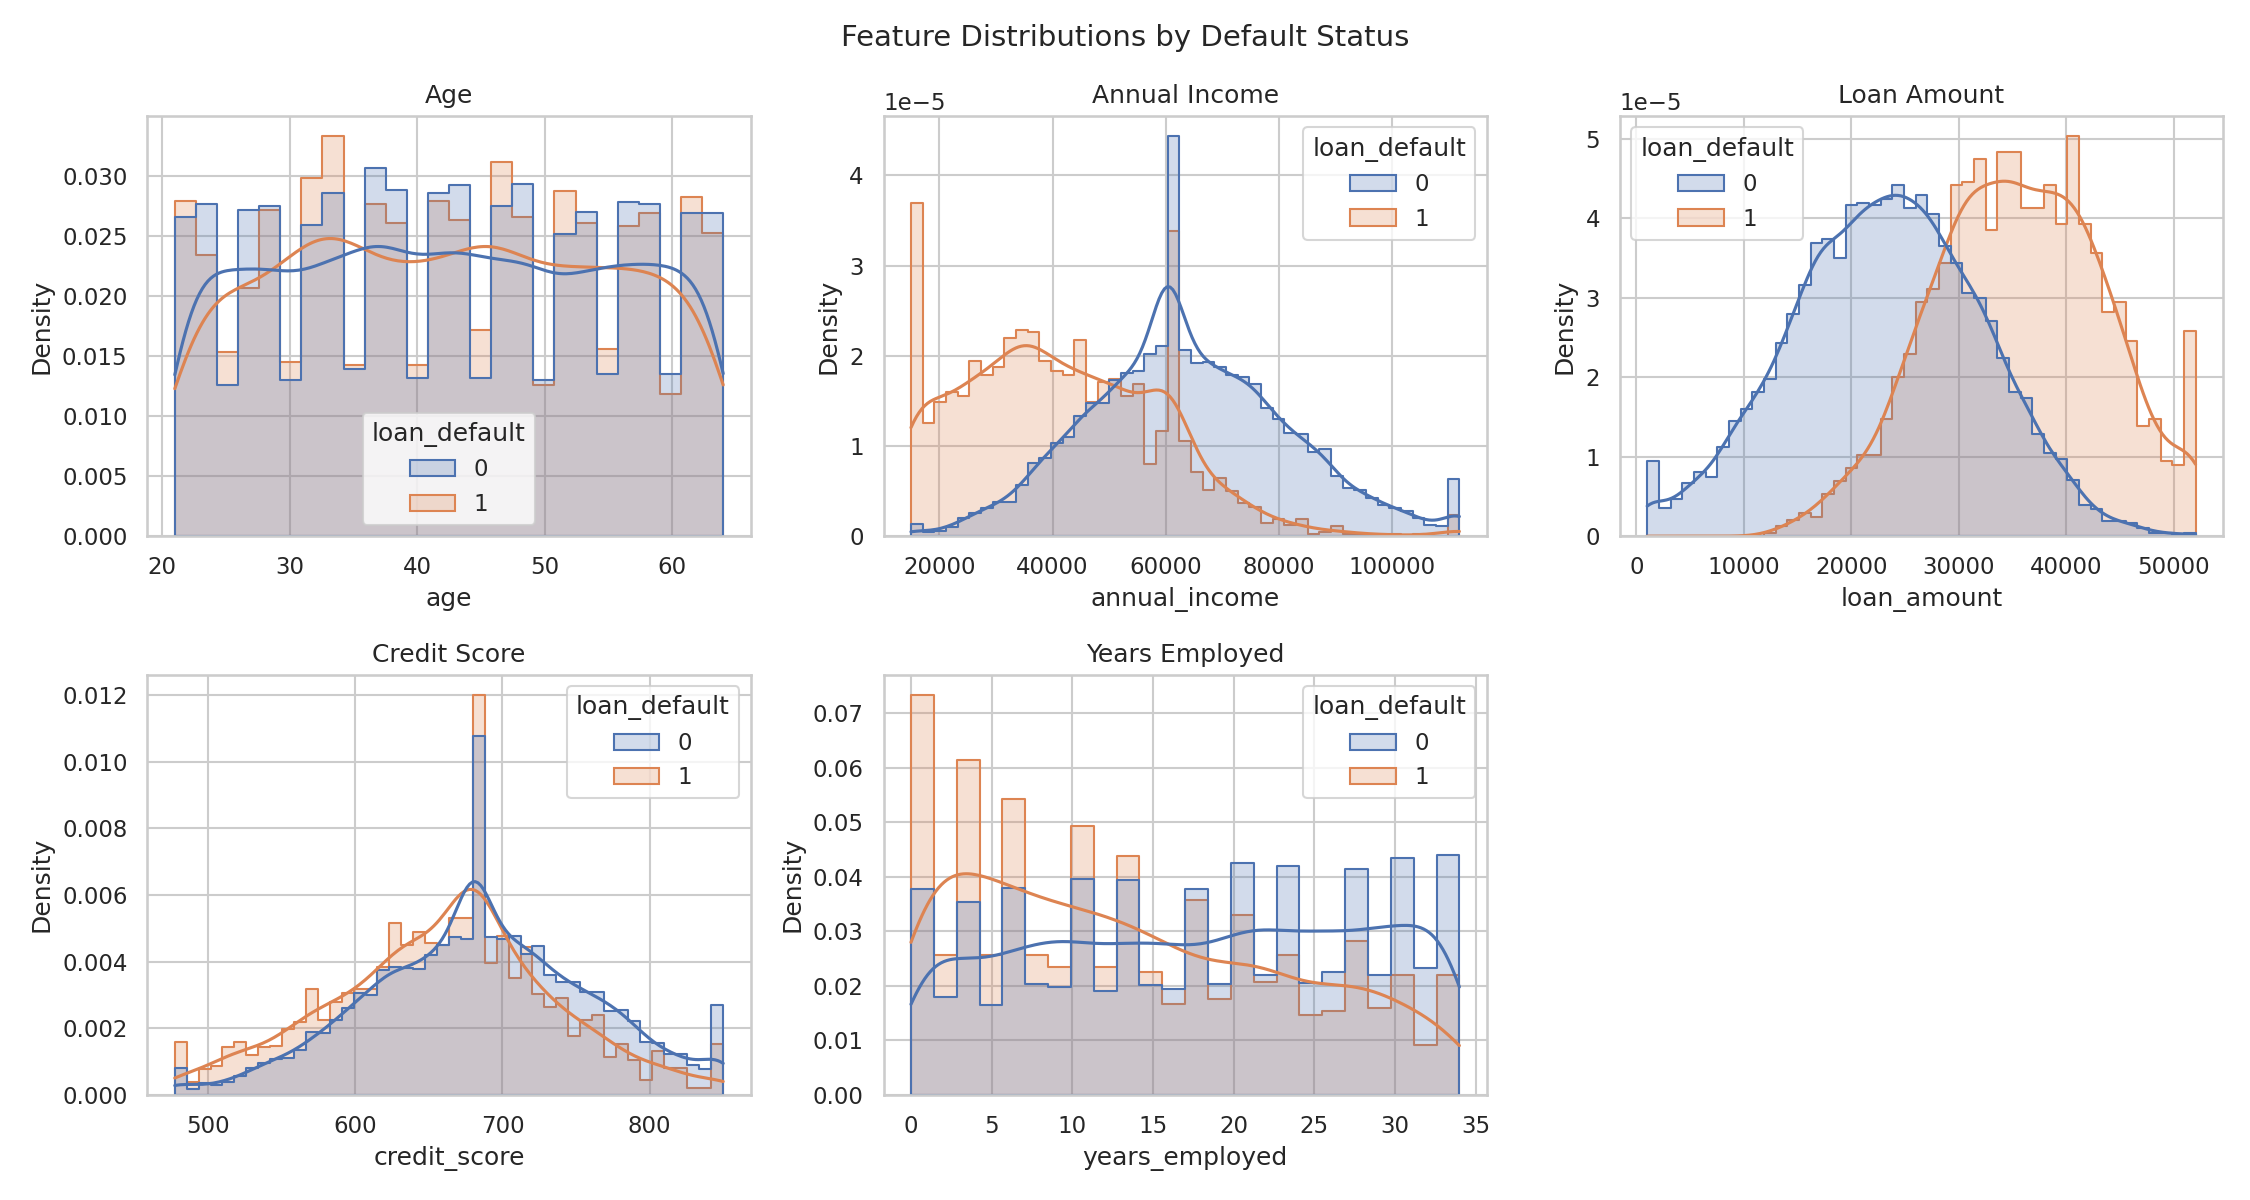

In [6]:
Image(filename="../images/numeric_distributions.png")


Defaulters skew toward **lower credit scores**, **shorter employment
tenure**, and **higher loan amounts relative to income** — all consistent
with standard credit-risk intuition.

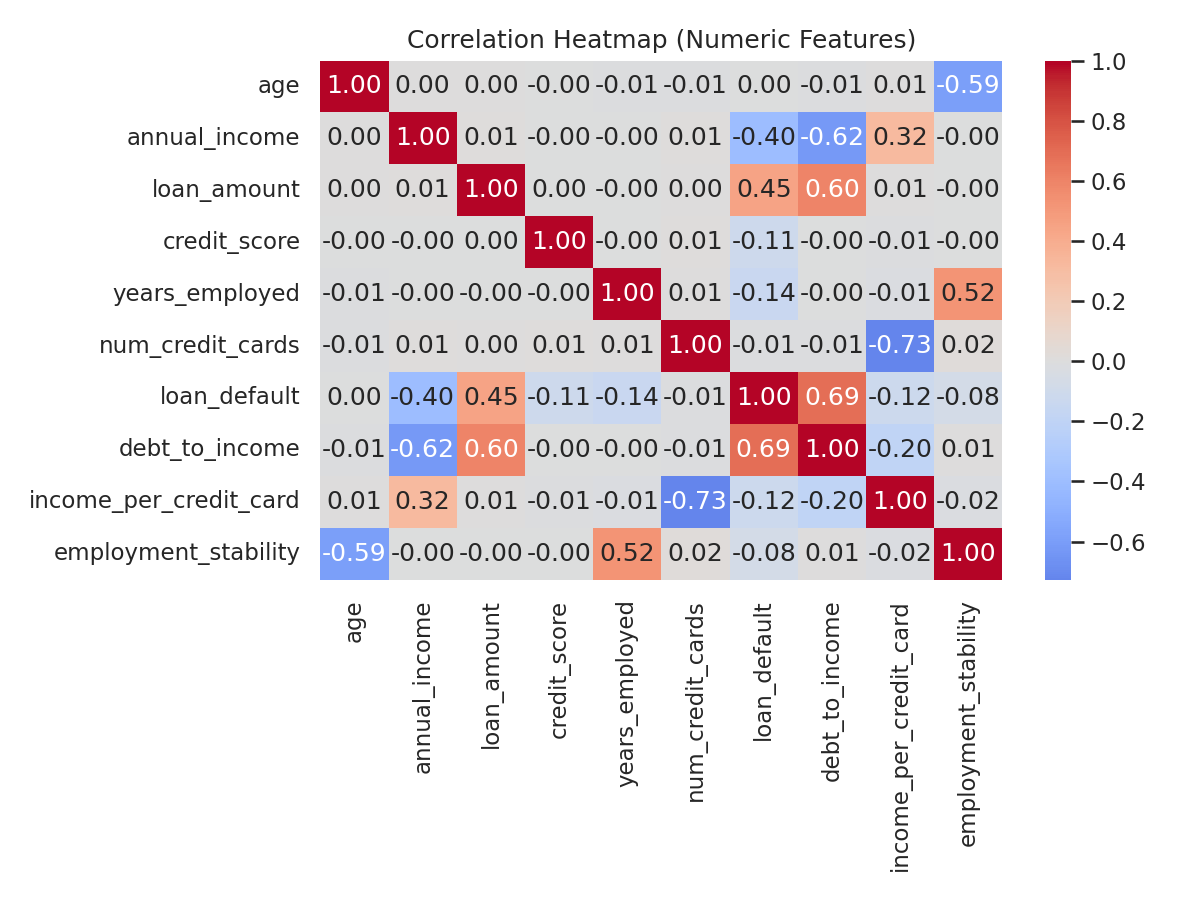

In [7]:
Image(filename="../images/correlation_heatmap.png")


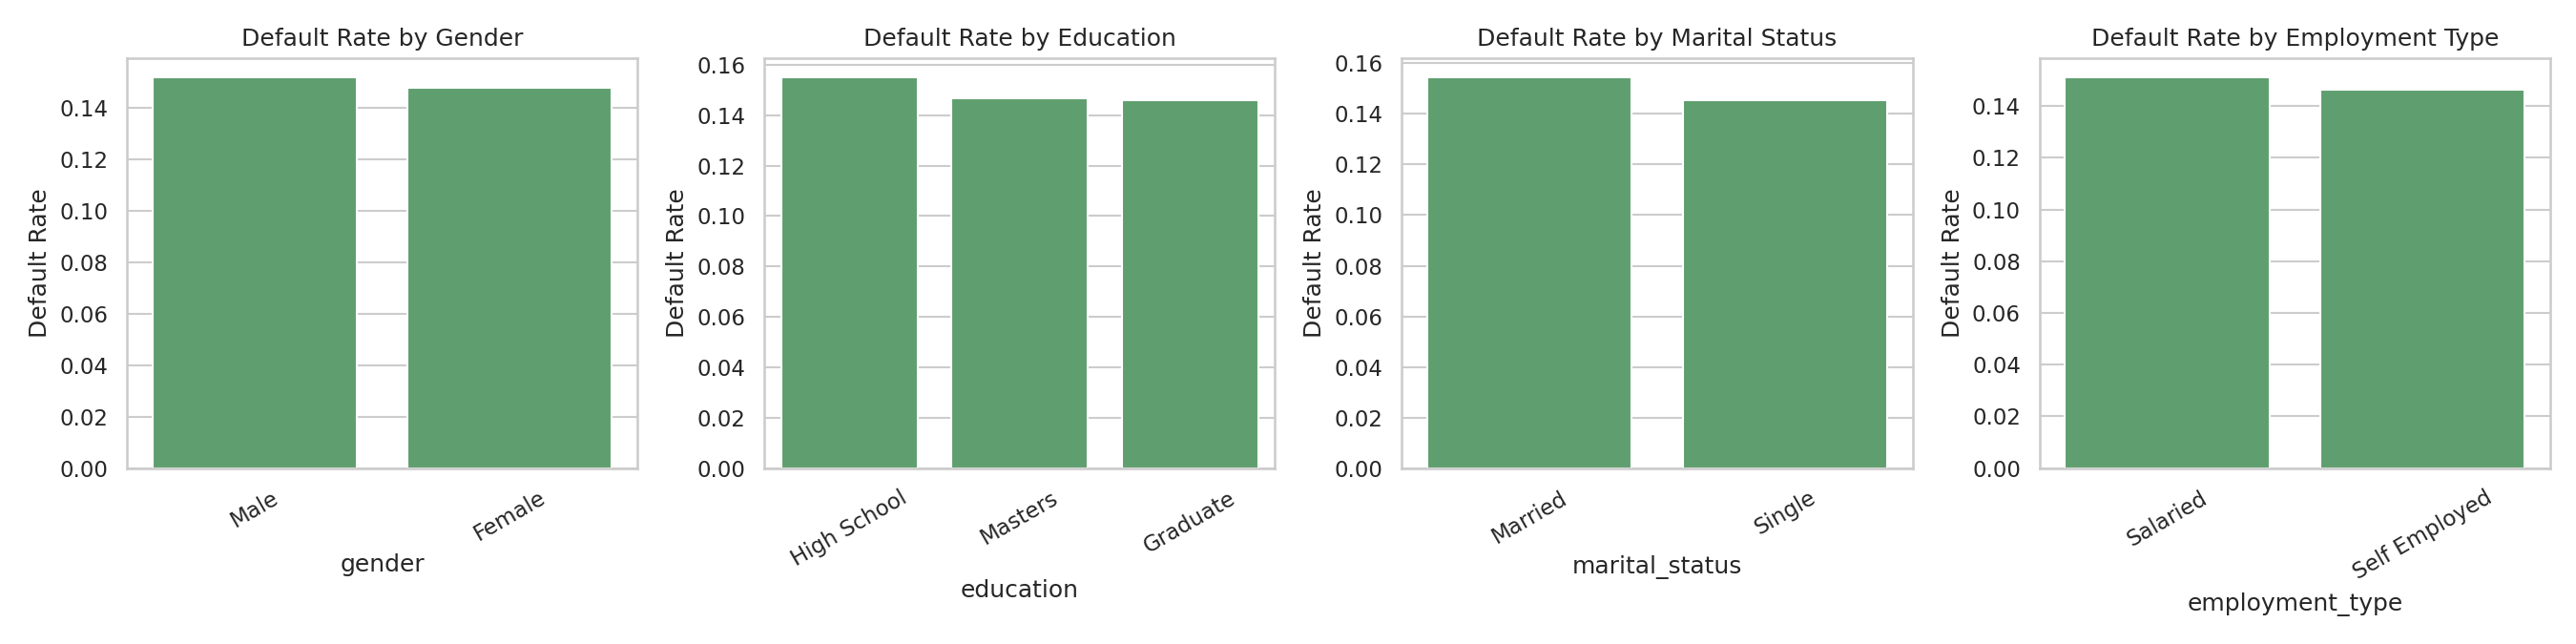

In [8]:
Image(filename="../images/categorical_default_rates.png")


## 3. Feature Engineering

In [9]:
df_fe = engineer_features(df)
df_fe[["debt_to_income", "income_per_credit_card", "employment_stability"]].describe()


,debt_to_income,income_per_credit_card,employment_stability
count,15000.000000,15000.000000,15000.000000
mean,0.474797,17738.107958,1.002885
std,0.309736,17604.228828,1.140222
min,0.008943,1500.000000,0.000000
25%,0.285907,7316.223295,0.321429
50%,0.412156,11084.319852,0.666667
75%,0.577353,20123.030817,1.192308
max,3.468853,111817.970921,8.500000


Three engineered features are added:
- **`debt_to_income`** — loan amount divided by annual income, a classic
  underwriting ratio
- **`income_per_credit_card`** — proxy for how thinly credit is spread
- **`employment_stability`** — years employed relative to years since age 17,
  a rough tenure-stability ratio

These turn out to meaningfully boost model performance over the raw fields
alone (see Section 5).

## 4. Train/Test Split and Preprocessing Pipeline

In [10]:
numeric, categorical = get_feature_lists()
X_train, X_test, y_train, y_test = train_test_split_data(df_fe)
preprocessor = build_preprocessor(numeric, categorical)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (12000, 13)
Test shape: (3000, 13)


## 5. Model Comparison

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

candidates = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

results = []
for name, clf in candidates.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("classifier", clf)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    probs = pipe.predict_proba(X_test)[:, 1]
    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds),
        "recall": recall_score(y_test, preds),
        "f1": f1_score(y_test, preds),
        "roc_auc": roc_auc_score(y_test, probs),
    })

results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False)
results_df


,model,accuracy,precision,recall,f1,roc_auc
2,Gradient Boosting,0.980000,0.966507,0.897778,0.930876,0.991676
1,Random Forest,0.972333,0.964557,0.846667,0.901775,0.987036
0,Logistic Regression,0.956000,0.792279,0.957778,0.867203,0.986423


**Gradient Boosting** comes out ahead on ROC-AUC and F1, so it's selected for
hyperparameter tuning. See `src/train_model.py` for the full `GridSearchCV`
sweep over `n_estimators`, `max_depth`, and `learning_rate` (run separately
since it's compute-heavy).

## 6. Final Model Evaluation

In [12]:
import joblib
final_model = joblib.load("../models/loan_default_model.joblib")

preds = final_model.predict(X_test)
probs = final_model.predict_proba(X_test)[:, 1]

print(f"Accuracy:  {accuracy_score(y_test, preds):.4f}")
print(f"Precision: {precision_score(y_test, preds):.4f}")
print(f"Recall:    {recall_score(y_test, preds):.4f}")
print(f"F1 score:  {f1_score(y_test, preds):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, probs):.4f}")


Accuracy:  0.9807
Precision: 0.9734
Recall:    0.8956
F1 score:  0.9329
ROC-AUC:   0.9917


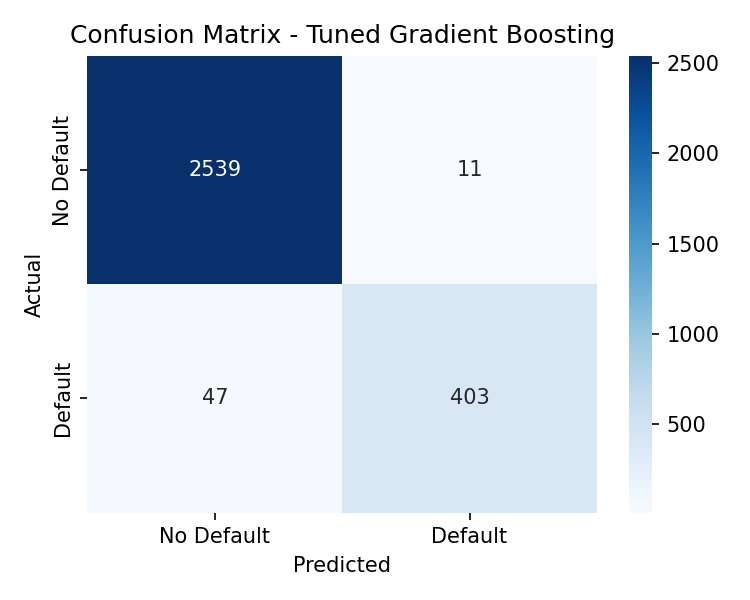

In [13]:
Image(filename="../images/confusion_matrix.png")


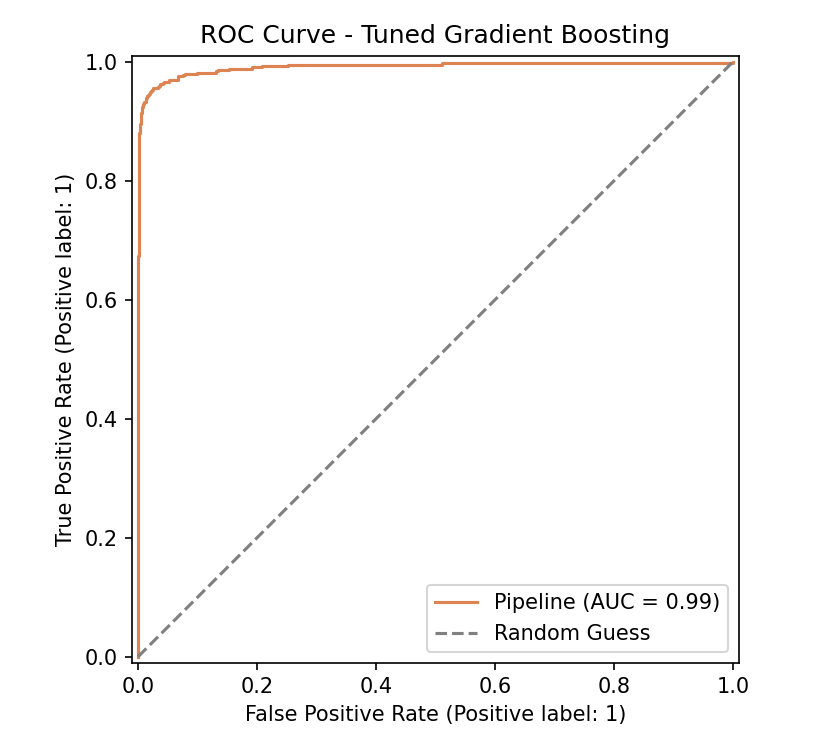

In [14]:
Image(filename="../images/roc_curve.png")


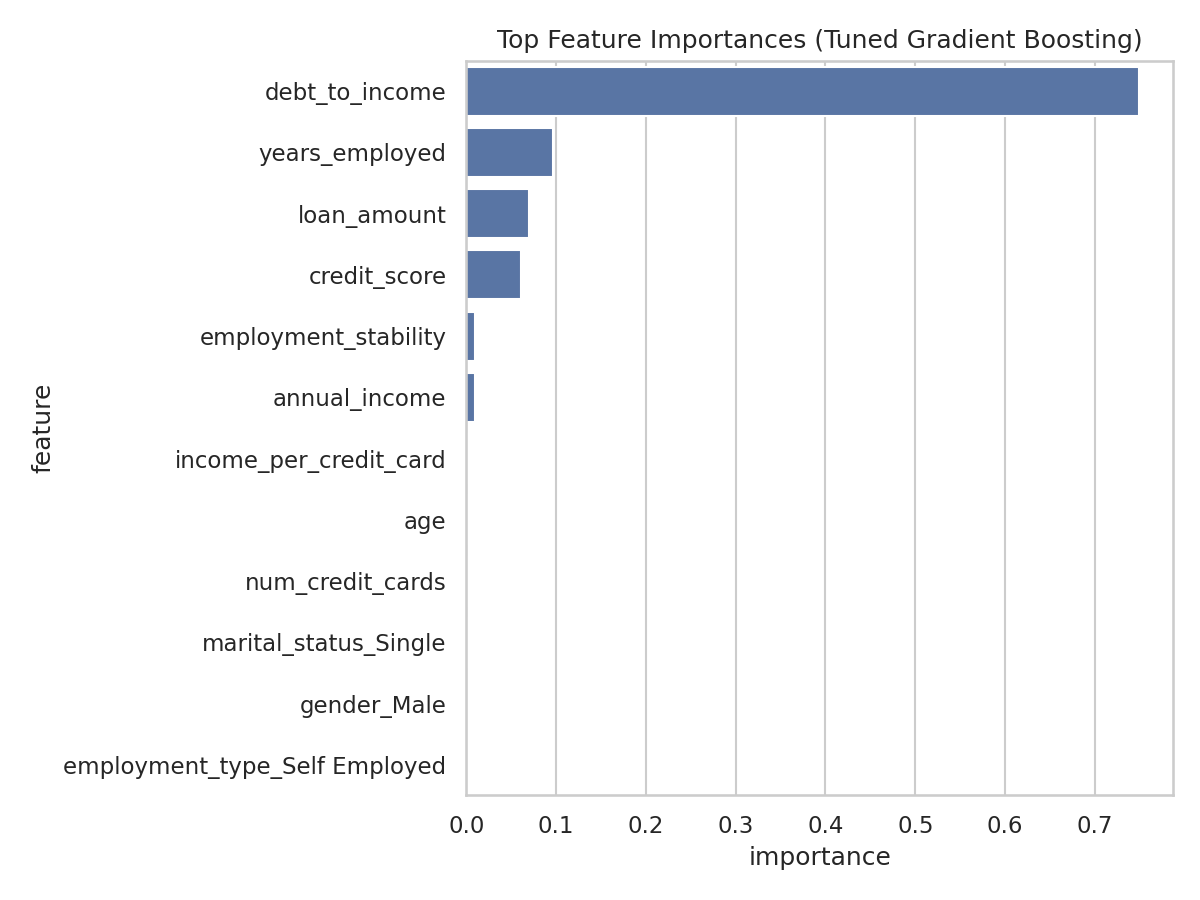

In [15]:
Image(filename="../images/feature_importance.png")


`debt_to_income` is by far the strongest predictor, consistent with how
lenders evaluate credit risk in practice — confirming the engineered
feature added real signal beyond the raw columns.

## 7. Scoring New Applicants

In [16]:
sys.path.append("../src")
from predict import predict_default_risk

new_applicants = pd.DataFrame([
    {
        "age": 29, "annual_income": 42000, "loan_amount": 38000,
        "credit_score": 590, "years_employed": 2, "num_credit_cards": 7,
        "gender": "Male", "education": "High School",
        "marital_status": "Single", "employment_type": "Self Employed",
    },
    {
        "age": 45, "annual_income": 95000, "loan_amount": 15000,
        "credit_score": 780, "years_employed": 18, "num_credit_cards": 2,
        "gender": "Female", "education": "Masters",
        "marital_status": "Married", "employment_type": "Salaried",
    },
])

predict_default_risk(new_applicants)


,age,annual_income,loan_amount,credit_score,years_employed,num_credit_cards,gender,education,marital_status,employment_type,default_probability,default_prediction
0,29,42000,38000,590,2,7,Male,High School,Single,Self Employed,0.9992,1
1,45,95000,15000,780,18,2,Female,Masters,Married,Salaried,0.0005,0


## 8. Conclusion

The tuned Gradient Boosting model reaches **~0.99 ROC-AUC** and **~0.93 F1**
on held-out test data, driven largely by debt-to-income ratio, employment
tenure, and credit score. This pipeline (preprocessing + model) is saved as
a single artifact (`models/loan_default_model.joblib`) and can be loaded
directly for scoring new applicants via `src/predict.py`.

**Possible extensions:**
- Calibrate predicted probabilities for use in risk-based pricing
- Add SHAP values for per-applicant explainability
- Test on real-world data with macroeconomic features (interest rates, region)
- Deploy as a REST API (e.g. FastAPI) for real-time underwriting
